In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('mtcars (1).csv')

In [7]:
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [8]:
df.shape

(32, 11)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 2.9 KB


In [10]:
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [12]:
x = df.drop('mpg',axis=1)
y = df['mpg']

In [13]:
from sklearn.preprocessing import PolynomialFeatures

In [14]:
polynomial_converter=PolynomialFeatures(degree=3,include_bias=False)

In [15]:
poly_features=polynomial_converter.fit_transform(x)

In [16]:
x.shape

(32, 10)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=49)

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
model = LinearRegression()

In [21]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
print("shape of original dataset:",df.shape)
print("shape of input - training set ", x_train.shape)
print("shape of output - training set ", y_train.shape)
print("shape of input - training set ", x_test.shape)
print("shape of output - training set ", y_test.shape)

shape of original dataset: (32, 11)
shape of input - training set  (22, 10)
shape of output - training set  (22,)
shape of input - training set  (10, 10)
shape of output - training set  (10,)


In [23]:
pd.DataFrame(model.coef_,x.columns,columns=['Coeficient'])

,Coeficient
cyl,2.779665
disp,0.009422
hp,0.014492
drat,3.772068
wt,-4.684462
qsec,2.209331
vs,1.711450
am,7.514773
gear,0.270410
carb,-1.388084


In [24]:
y_pred=model.predict(x_test)

In [25]:
pd.DataFrame({'Y_Test':y_test,'Y_Pred':y_pred,
             'Residuals':(y_test-y_pred)}).head() 

,Y_Test,Y_Pred,Residuals
30,15.0,15.790377,-0.790377
2,22.8,26.388022,-3.588022
15,10.4,9.438350,0.961650
7,24.4,15.792510,8.607490
9,19.2,15.597227,3.602773


In [26]:
from sklearn import metrics
MAE_Poly = metrics.mean_absolute_error(y_test,y_pred)
MSE_Poly = metrics.mean_squared_error(y_test,y_pred)
RMSE_Poly = np.sqrt(MSE_Poly)
pd.DataFrame([MAE_Poly,MSE_Poly,RMSE_Poly],
            index=['MAE','MSE','RMSE'],columns=['metrics'])

,metrics
MAE,4.487929
MSE,26.995996
RMSE,5.195767


In [27]:
train_RMSE_list=[]
test_RMSE_list=[]

In [28]:
for d in range(1,10):
    polynomial_converter=PolynomialFeatures(degree=d,include_bias=False)
    poly_features = polynomial_converter.fit(x)
    poly_features = polynomial_converter.transform(x)

    x_train,x_test,y_train,y_test=train_test_split(poly_features,y,test_size=0.3,random_state=101)

    polymodel = LinearRegression()
    polymodel.fit(x_train,y_train)

    y_train_pred=polymodel.predict(x_train)
    y_test_pred=polymodel.predict(x_test)

    train_RMSE=np.sqrt(metrics.mean_squared_error(y_train,y_train_pred))
    test_RMSE=np.sqrt(metrics.mean_squared_error(y_test,y_test_pred))
    train_RMSE_list.append(train_RMSE)
    test_RMSE_list.append(test_RMSE)

In [29]:
train_RMSE_list

[np.float64(1.4953121903985127),
 np.float64(3.6216335978674208e-12),
 np.float64(7.312957524020422e-13),
 np.float64(1.3586879371976616e-12),
 np.float64(9.945328760300215e-12),
 np.float64(8.909393750209474e-12),
 np.float64(2.4826547538968703e-10),
 np.float64(5.150710933413482e-10),
 np.float64(2.333705496055928e-09)]

In [30]:
test_RMSE_list

[np.float64(4.332830783335176),
 np.float64(27.882587349084766),
 np.float64(19.830675101404807),
 np.float64(31.55883270381415),
 np.float64(54.05500382336357),
 np.float64(291.7592402812629),
 np.float64(1331.0523165364107),
 np.float64(5737.193984036317),
 np.float64(25939.679339082046)]

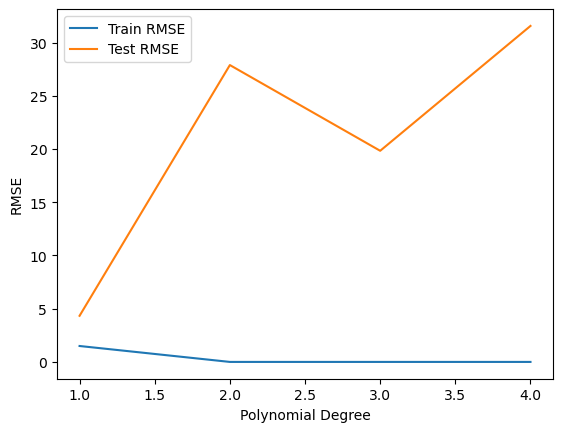

In [33]:
plt.plot(range(1,5), train_RMSE_list[:4],label='Train RMSE')
plt.plot(range(1,5), test_RMSE_list[:4],label='Test RMSE')

plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.legend()